# adm to city

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
org_data = pd.read_csv( '../../sample_table/ewma_6h_scaling.csv')
org_data = org_data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd' , 'humid' , 'temp', 'precip_form', 'precip', 'isHoliday']]

In [14]:
agg_df = pd.DataFrame()
agg_df['count']       = org_data.groupby('REG_DTIME')['count'].sum()   # s나중에 rounding 한 데이터도 생성 후 학습
agg_df['pops']        = org_data.groupby('REG_DTIME')['pops'].min()
agg_df['windspd']     = org_data.groupby('REG_DTIME')['windspd'].max()
agg_df['humind']      = org_data.groupby('REG_DTIME')['humid'].min()
agg_df['temp']        = org_data.groupby('REG_DTIME')['temp'].min()
agg_df['precip_form'] = org_data.groupby('REG_DTIME')['precip_form'].max()
agg_df['precip']      = org_data.groupby('REG_DTIME')['precip'].max()
agg_df['isHoliday']   = org_data.groupby('REG_DTIME')['isHoliday'].mean()
agg_df['h_dong']      = np.full(len(agg_df), 'ch')
agg_df.reset_index(inplace=True)
agg_df.to_csv('org_data.csv')
agg_df

,REG_DTIME,count,pops,windspd,humind,temp,precip_form,precip,isHoliday,h_dong
0,2021-01-01 00:00:00,0.000000,959,1.0,48.0,-10.300000,0.0,0.0,1.0,ch
1,2021-01-01 01:00:00,0.000000,959,3.2,40.0,-6.700000,0.0,0.0,1.0,ch
2,2021-01-01 02:00:00,0.000000,959,2.2,39.0,-3.700000,0.0,0.0,1.0,ch
3,2021-01-01 03:00:00,0.000000,959,3.1,37.0,-2.200000,0.0,0.0,1.0,ch
4,2021-01-01 04:00:00,0.000000,959,3.6,36.0,-1.000000,0.0,0.0,1.0,ch
...,...,...,...,...,...,...,...,...,...,...
8755,2021-12-31 19:00:00,3.076923,959,0.7,73.0,-16.700001,0.0,0.0,0.0,ch
8756,2021-12-31 20:00:00,2.307692,959,0.7,77.0,-16.900000,0.0,0.0,0.0,ch
8757,2021-12-31 21:00:00,1.692308,959,1.1,76.0,-17.100000,0.0,0.0,0.0,ch
8758,2021-12-31 22:00:00,1.846154,959,0.8,77.0,-16.700001,0.0,0.0,0.0,ch


In [15]:
agg_df['count'] = agg_df['count'].round()
agg_df.to_csv('data_rounding.csv')

# check data to histogram

각 column 별로 데이터 분포 확인후 aggregate할 때 가장 적절한 함수 설정(min, max, mean 사용)

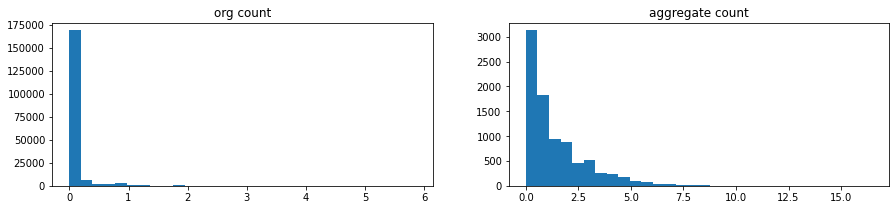

In [16]:
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['count'] , bins=30)
axes[0].set_title('org count')
axes[1].hist(org_data.groupby('REG_DTIME')['count'].sum(),bins=30)
axes[1].set_title('aggregate count')

plt.show()

# 추후에 rounding 한것도 학습 시키기

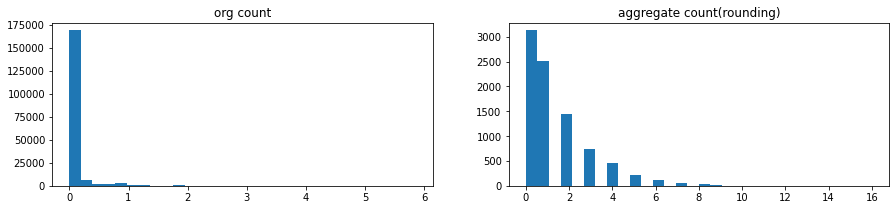

In [19]:
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['count'] , bins=30)
axes[0].set_title('org count')
axes[1].hist(agg_df['count'],bins=30)
axes[1].set_title('aggregate count(rounding)')

plt.show()

# 추후에 rounding 한것도 학습 시키기

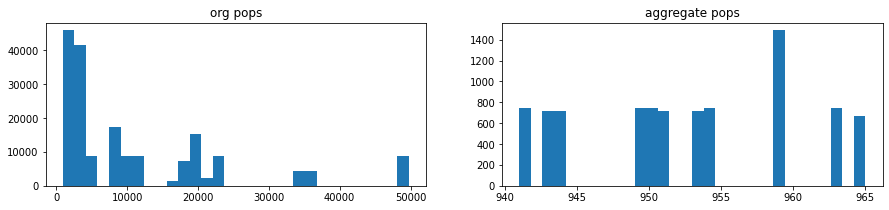

In [21]:
# 데이터 다시 확인
# 인구 데이터는 aggregate를 해도 별 차이가 나면 완됨  
# 우선 보류 
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['pops'],bins=30)
axes[0].set_title('org pops')
axes[1].hist(org_data.groupby('REG_DTIME')['pops'].min(), bins=30)
axes[1].set_title('aggregate pops')

plt.show()

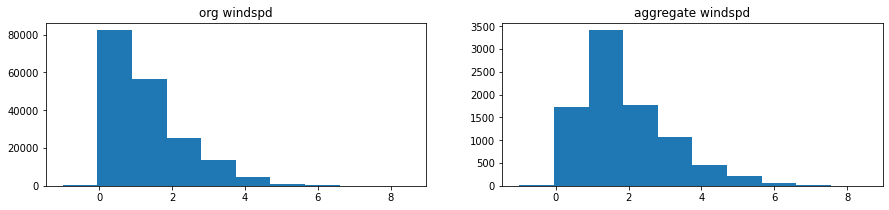

In [22]:
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['windspd'])
axes[0].set_title('org windspd')
axes[1].hist(org_data.groupby('REG_DTIME')['windspd'].max())
axes[1].set_title('aggregate windspd')

plt.show()

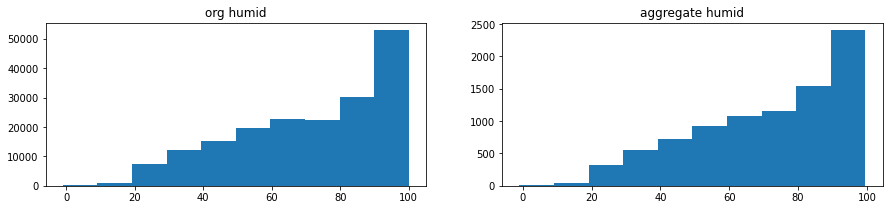

In [24]:
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['humid'])
axes[0].set_title('org humid')
axes[1].hist(org_data.groupby('REG_DTIME')['humid'].mean())
axes[1].set_title('aggregate humid')

plt.show()

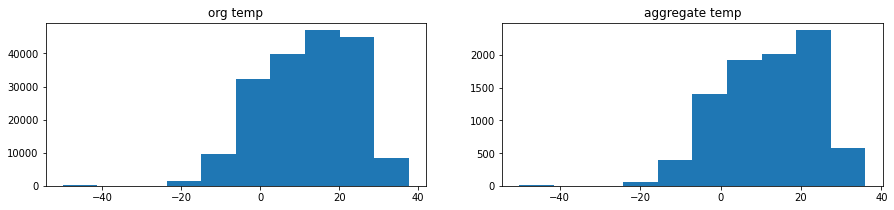

In [25]:
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['temp'])
axes[0].set_title('org temp')
axes[1].hist(org_data.groupby('REG_DTIME')['temp'].mean())
axes[1].set_title('aggregate temp')

plt.show()

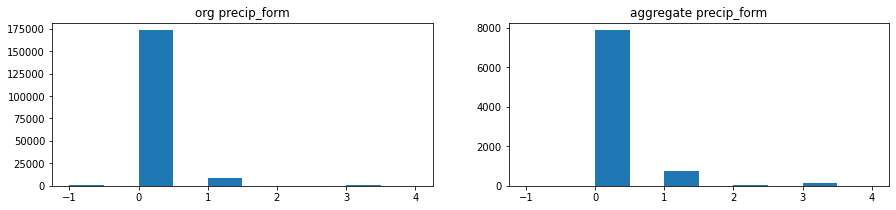

In [26]:
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['precip_form'])
axes[0].set_title('org precip_form')
axes[1].hist(org_data.groupby('REG_DTIME')['precip_form'].max())
axes[1].set_title('aggregate precip_form')

plt.show()

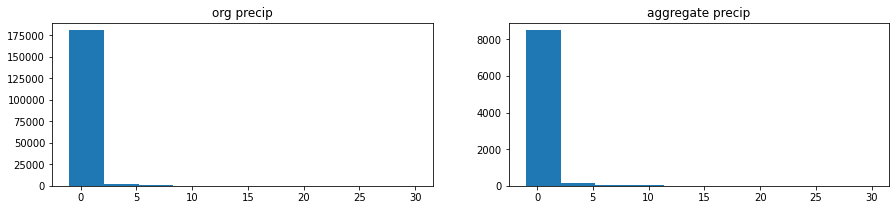

In [27]:
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['precip'])
axes[0].set_title('org precip')
axes[1].hist(org_data.groupby('REG_DTIME')['precip'].max())
axes[1].set_title('aggregate precip')

plt.show()

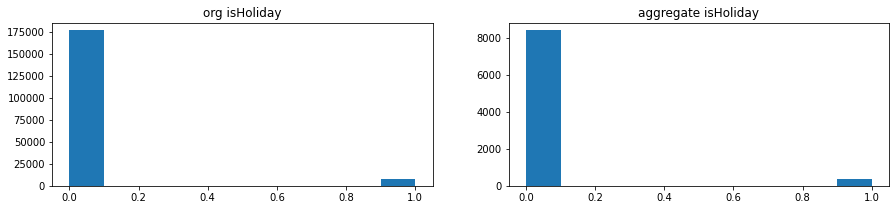

In [28]:
f , axes = plt.subplots(1,2 , figsize=(15,3))

axes[0].hist(org_data['isHoliday'].astype(int))
axes[0].set_title('org isHoliday')
axes[1].hist(org_data.groupby('REG_DTIME')['isHoliday'].mean())
axes[1].set_title('aggregate isHoliday')

plt.show()

# data describe


In [230]:
data = pd.read_csv('data.csv')
data.describe()

,Unnamed: 0,count,pops,windspd,humind,temp,precip_form,precip,isHoliday
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,4379.500000,1.440148,952.534247,1.871975,66.569178,9.842432,0.131735,0.236142,0.041096
std,2528.938512,1.556861,7.422129,1.204936,22.587795,11.794653,0.462546,1.314184,0.198523
min,0.000000,0.000000,941.000000,-1.000000,-1.000000,-50.000000,-1.000000,-1.000000,0.000000
25%,2189.750000,0.307692,949.000000,0.900000,50.000000,0.800000,0.000000,0.000000,0.000000
50%,4379.500000,0.923077,951.000000,1.600000,70.000000,11.400000,0.000000,0.000000,0.000000
75%,6569.250000,2.000000,959.000000,2.500000,87.000000,19.200001,0.000000,0.000000,0.000000
max,8759.000000,16.461538,965.000000,8.500000,97.000000,34.799999,4.000000,30.000000,1.000000


In [214]:
round_data = pd.read_csv('data_rounding.csv')
round_data.describe()

,Unnamed: 0,count,pops,windspd,humind,temp,precip_form,precip,isHoliday
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,4379.500000,1.400457,952.534247,1.871975,66.569178,9.842432,0.131735,0.236142,0.041096
std,2528.938512,1.609823,7.422129,1.204936,22.587795,11.794653,0.462546,1.314184,0.198523
min,0.000000,0.000000,941.000000,-1.000000,-1.000000,-50.000000,-1.000000,-1.000000,0.000000
25%,2189.750000,0.000000,949.000000,0.900000,50.000000,0.800000,0.000000,0.000000,0.000000
50%,4379.500000,1.000000,951.000000,1.600000,70.000000,11.400000,0.000000,0.000000,0.000000
75%,6569.250000,2.000000,959.000000,2.500000,87.000000,19.200001,0.000000,0.000000,0.000000
max,8759.000000,16.000000,965.000000,8.500000,97.000000,34.799999,4.000000,30.000000,1.000000


# orginal data vs. aggregated data count

In [237]:
org_len = len(org_data[org_data['count'] > 0]) / len(org_data)
data_len = len(data[data['count'] > 0]) / len(data)

print(f'orginal data   에서 count가 0 이상인 비율 {org_len}')
print(f'aggregated data에서 count가 0 이상인 비율 {data_len}')

orginal data   에서 count가 0 이상인 비율 0.12653837790824093
aggregated data에서 count가 0 이상인 비율 0.8734018264840183


Text(0.5, 1.0, 'org_data count ')

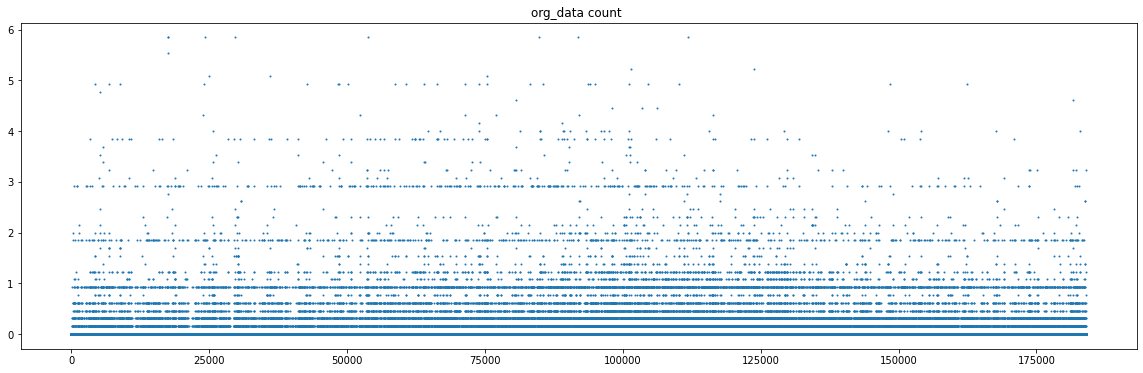

In [239]:
plt.figure(figsize=(20,6))
x = range(len(org_data))
plt.scatter(x , org_data['count'], s=1)
plt.title('org_data count ')

Text(0.5, 1.0, 'aggregated_data count ')

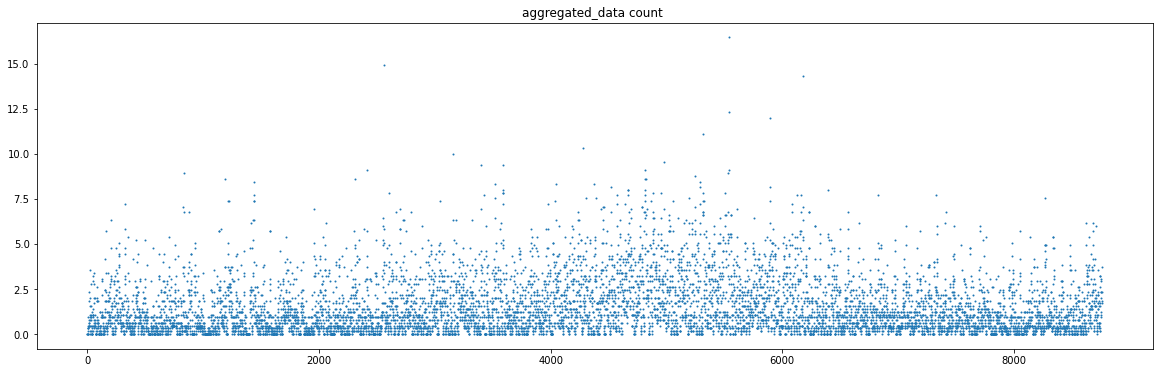

In [240]:
plt.figure(figsize=(20,6))
x = range(len(data))
plt.scatter(x , data['count'], s=1)
plt.title('aggregated_data count ')